#Python modules

In [7]:
import pandas as pd
import numpy as np
import datetime as dt
from pandas_datareader import data as pdr
import yfinance as yf


Import of data

In [8]:
def getData(stocks, start, end):
    data = yf.download(stocks, start=start, end=end)
    stockData= data['Close']
    returns= stockData.pct_change()
    meanReturns= returns.mean()
    covMatrix= returns.cov()
    return returns, meanReturns, covMatrix


#Portfolio performance

In [9]:
def PortfolioPerformance(weights, meanReturns, covMatrix, Time):
    returns= np.sum(meanReturns*weights)*Time
    std= np.sqrt(np.dot(weights.T, np.dot(covMatrix, weights)))*np.sqrt(Time)
    return returns, std

In [19]:
stockList=["AMZN", "NVDA", "MSFT", "MDB"]
endDate= dt.datetime.now()
startDate= endDate-dt.timedelta(days=300)

returns, meanReturns, covMatrix= getData(stockList, startDate, endDate)
returns= returns.dropna()
print(returns)


/tmp/ipykernel_193/876069044.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start=start, end=end)
[*********************100%***********************]  4 of 4 completed

Ticker          AMZN       MDB      MSFT      NVDA
Date                                              
2025-05-09  0.005102 -0.004017  0.001278 -0.006135
2025-05-12  0.080700  0.073205  0.024001  0.054436
2025-05-13  0.013085  0.022389 -0.000267  0.056341
2025-05-14 -0.005299 -0.011026  0.008461  0.041638
2025-05-15 -0.024162 -0.016723  0.002256 -0.003768
...              ...       ...       ...       ...
2026-02-25  0.009973  0.007936  0.029820  0.014052
2026-02-26 -0.012913  0.068637  0.002796 -0.054561
2026-02-27  0.010004 -0.024182 -0.022354 -0.041646
2026-03-02 -0.007667 -0.010534  0.014793  0.029855
2026-03-03  0.001632 -0.222393  0.013499 -0.013316

[204 rows x 4 columns]


<Axes: xlabel='Date'>

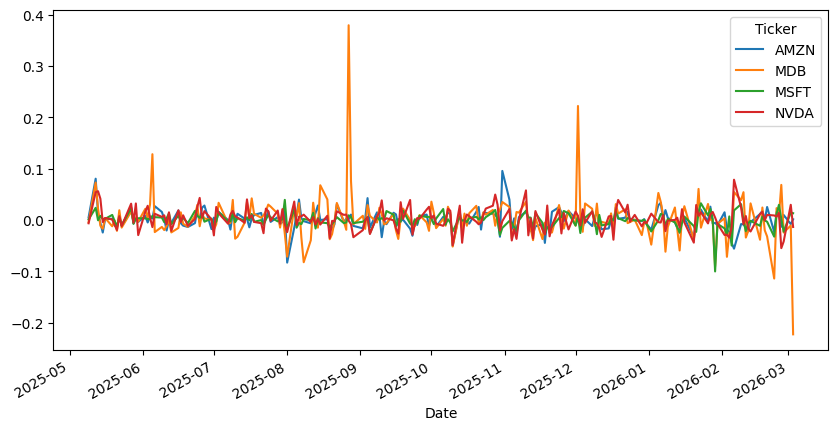

In [18]:
returns.plot(figsize=(10,5))

In [27]:
weights= np.random.random(len(returns.columns))
weights/= np.sum(weights)
returns['portfolio'] = returns.dot(weights)
print(returns)

Ticker          AMZN       MDB      MSFT      NVDA  portfolio
Date                                                         
2025-05-09  0.005102 -0.004017  0.001278 -0.006135  -0.002266
2025-05-12  0.080700  0.073205  0.024001  0.054436   0.058158
2025-05-13  0.013085  0.022389 -0.000267  0.056341   0.034418
2025-05-14 -0.005299 -0.011026  0.008461  0.041638   0.020116
2025-05-15 -0.024162 -0.016723  0.002256 -0.003768  -0.009019
...              ...       ...       ...       ...        ...
2026-02-25  0.009973  0.007936  0.029820  0.014052   0.014703
2026-02-26 -0.012913  0.068637  0.002796 -0.054561  -0.022624
2026-02-27  0.010004 -0.024182 -0.022354 -0.041646  -0.025114
2026-03-02 -0.007667 -0.010534  0.014793  0.029855   0.014505
2026-03-03  0.001632 -0.222393  0.013499 -0.013316  -0.030104

[204 rows x 5 columns]


array([[<Axes: title={'center': 'AMZN'}>,
        <Axes: title={'center': 'MDB'}>],
       [<Axes: title={'center': 'MSFT'}>,
        <Axes: title={'center': 'NVDA'}>],
       [<Axes: title={'center': 'portfolio'}>, <Axes: >]], dtype=object)

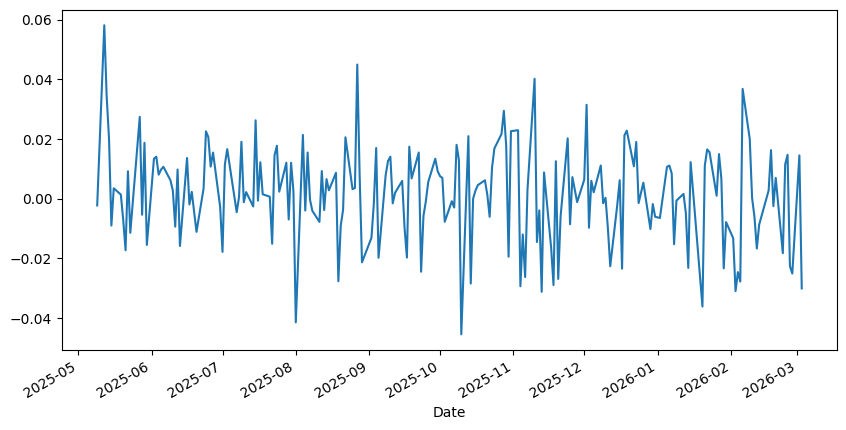

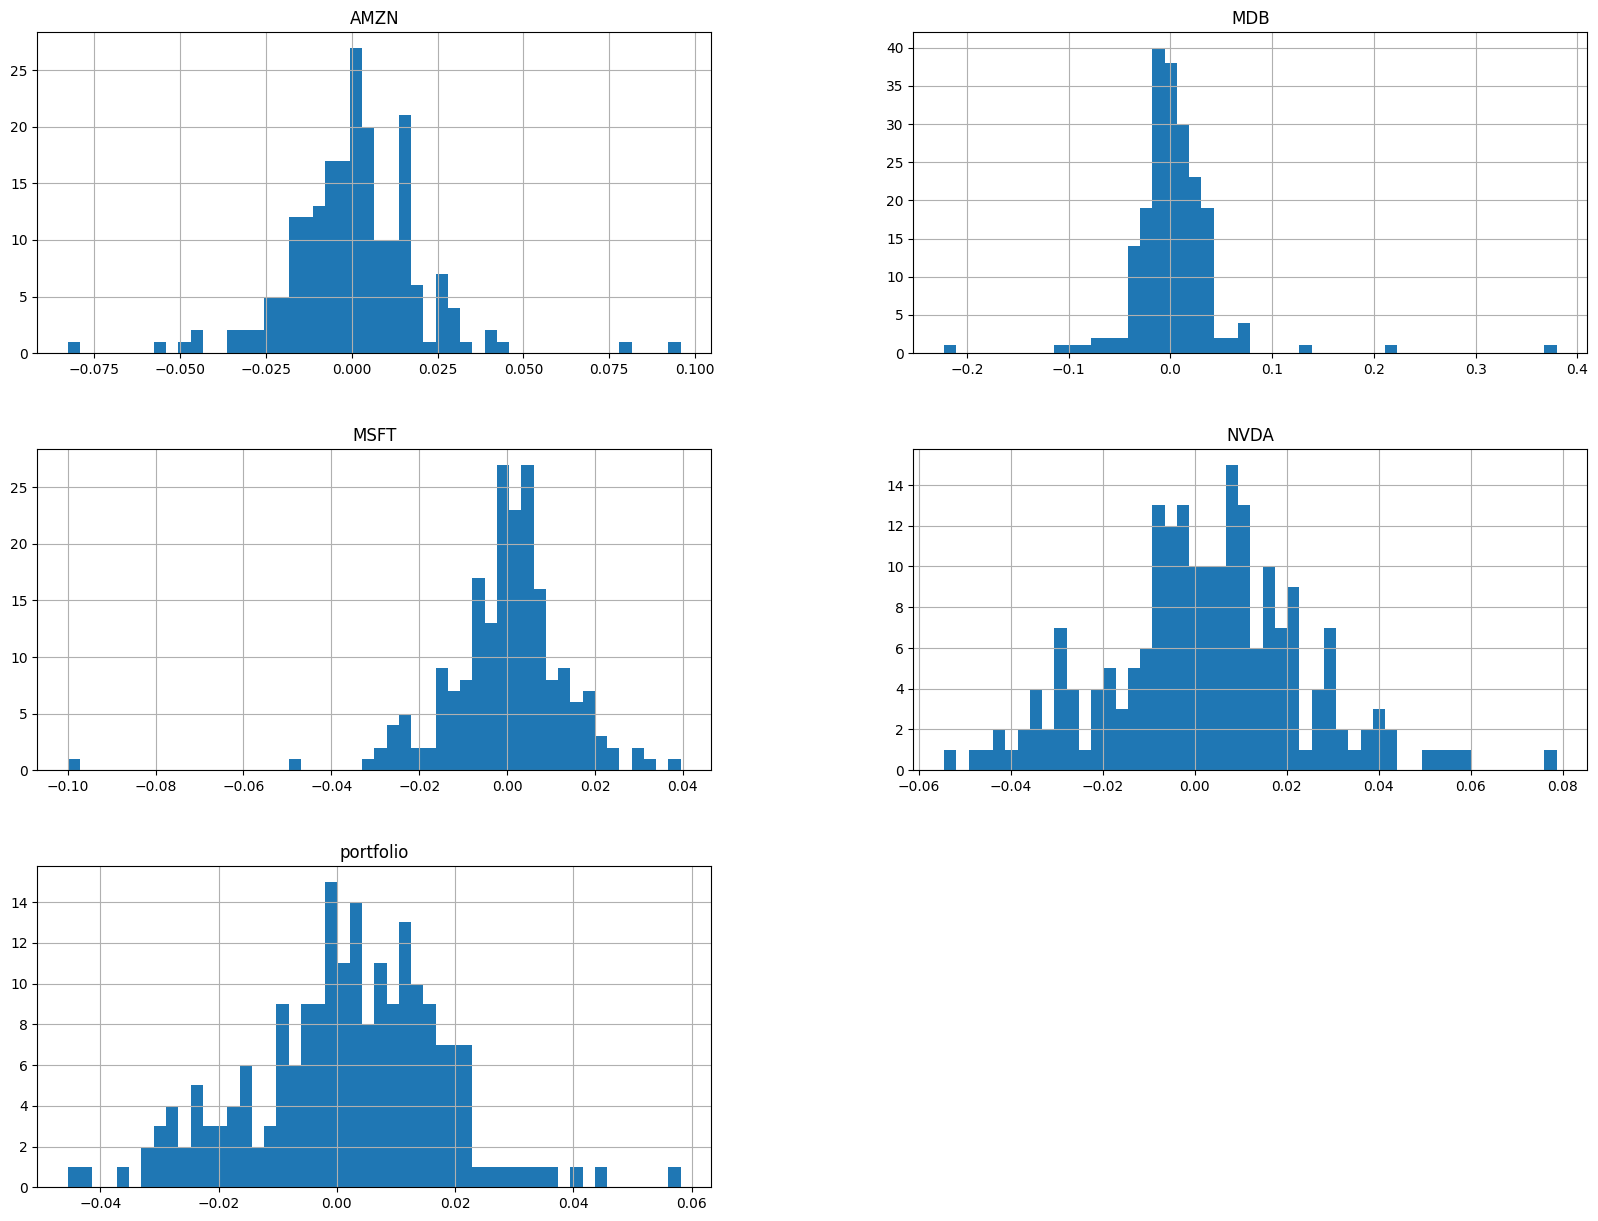

In [37]:
returns["portfolio"].plot(figsize=(10,5))
returns.hist(bins=50, figsize=(20,15))

In [39]:
def historicalVaR (returns, alpha=5):

  if isinstance(returns, pd.Series):
    return np.percentile(returns, alpha)

  elif isinstance(returns, pd.DataFrame):
    return returns.aggregate(historicalVaR, alpha=5)

  else: raise TypeError("Expected returns to be dataframe or series")

def historicalCVaR(returns, alpha=5 ):

  if isinstance(returns, pd.Series):
    belowVaR= returns <= historicalVaR(returns, alpha=alpha)
    return returns[belowVaR].mean()

  elif isinstance(returns, pd.DataFrame):
    return returns.aggregate(historicalCVaR, alpha=5)

  else: raise TypeError("Expected returns to be dataframe or series")



Time=1

Var=-historicalVaR(returns["portfolio"], alpha=5 )*np.sqrt(Time)
CVaR=-historicalCVaR(returns["portfolio"], alpha=5 )*np.sqrt(Time)

# Adjust weights to match the number of assets in meanReturns
# The original 'weights' array includes a weight for the 'portfolio' column,
# which is incorrect for the PortfolioPerformance calculation.
# We take the first `len(meanReturns)` elements, assuming they correspond to the stocks.
weights_for_performance = weights[:len(meanReturns)]

pRet, pStd= PortfolioPerformance(weights_for_performance, meanReturns, covMatrix, Time)

Capital= 100000
print("Expected Portfolio return: ", round(Capital*pRet, 2))
print("Value at Risk at 95th CI: ", round(Capital*Var, 2))
print("Conditional Value at Risk at 95th CI: ", round(Capital*CVaR, 2))

Expected Portfolio return:  100.82
Value at Risk at 95th CI:  2758.72
Conditional Value at Risk at 95th CI:  3252.87
